In [24]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.data.data_loader import DataLoad
from src.data.process_data import ProcessData
from src.models.rolling_gridsearch import RollingGridSearch
from src.portfolio.bl_optimization import BlackLitterman
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
import math
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression, Lasso

In [2]:
# load in backtesting datasets, cut off at end of train data, will use that to test out backtesting

dl = DataLoad()
backtest = dl.load_dataset("model")
backtest = backtest[backtest.index <= "2016-12-31"]
daily_stock_returns, monthly_stock_returns = dl.load_dataset("returns")
daily_stock_returns = daily_stock_returns[daily_stock_returns.index <= "2016-12-31"]
monthly_stock_returns = monthly_stock_returns[monthly_stock_returns.index <= "2016-12-31"]

model.csv loaded succesfully
daily_stock_returns.csv loaded succesfully
monthly_stock_returns.csv loaded succesfully


In [3]:
# for this test, assume until 2016 is "test" and then 2016 01 - 12 is the backtest

In [4]:
# first things is build baselines, this investigation will have 4 baselines:
# 1. Buy and hold S&P500, the index will be used, GSPC
# 2. Equally weighted portfolio with monthly rebalance, so 1/30 into each stock, rebalance every month
# 3. Black Litterman with no model predictions, so using baseline equilibrium, construct optimal portfolio
# 4. Black Litterman with random predictions, a monte carlo baseline, then construct optimal portfolio

# then move onto real backtest

In [5]:
# months of backtest

backtest_months = backtest[backtest.index >= "2016-01-01"].index.unique()
first_month = backtest_months[0]
backtest_days = daily_stock_returns[daily_stock_returns.index > first_month].index.unique()


In [6]:
dataprocess = ProcessData()
rfr = dataprocess.process_risk_free_rate()
rfr

GS3M.csv processed succesfully


np.float64(0.002054012345679013)

In [7]:
# all the metrics we will be calculating

def portfolio_volatility(monthly_returns):

    return np.std(monthly_returns, ddof=1)

def sharpe_ratio(monthly_returns, risk_free_rate):
    mean_returns = np.mean(monthly_returns)
    vol_returns = np.std(monthly_returns, ddof=1)
    monthly_sharpe = (mean_returns - risk_free_rate) / vol_returns
    annualized_sharpe = monthly_sharpe * np.sqrt(12)

    return annualized_sharpe

def sortino_ratio(monthly_returns, risk_free_rate):
    excess = monthly_returns - risk_free_rate
    downside = np.minimum(excess, 0)
    downside_dev = np.sqrt(np.mean(downside ** 2))

    annualized_sortino = (np.mean(excess) / downside_dev) * np.sqrt(12)

    return annualized_sortino

def drawdowns(portfolio_values):
    portfolio_values = pd.Series(portfolio_values)
    running_peak = portfolio_values.cummax()
    drawdowns = (portfolio_values / running_peak) - 1

    return drawdowns

def max_drawdown(drawdowns):
    
    return np.min(drawdowns)

def average_drawdown_depth(drawdowns):
    drawdowns = pd.Series(drawdowns)
    in_dd = drawdowns < 0
    groups = (in_dd != in_dd.shift()).cumsum()
    troughs = drawdowns.groupby(groups).min()
    troughs = troughs[troughs < 0]

    if len(troughs) == 0:
        return 0.0

    return troughs.mean()

def max_drawdown_duration(portfolio_values):
    portfolio_values = pd.Series(portfolio_values)
    in_dd = portfolio_values < portfolio_values.cummax()
    groups = (in_dd != in_dd.shift()).cumsum()
    durations = in_dd.groupby(groups).sum()

    if len(durations) == 0:
        return 0

    return durations.max()

def average_drawdown_duration(portfolio_values):
    portfolio_values = pd.Series(portfolio_values)
    in_dd = portfolio_values < portfolio_values.cummax()
    groups = (in_dd != in_dd.shift()).cumsum()
    durations = in_dd.groupby(groups).sum()
    durations = durations[durations > 0]

    if len(durations) == 0:
        return 0.0

    return durations.mean()

def ulcer_index(drawdowns):

    return np.sqrt(np.mean(np.power(drawdowns,2)))

def var(monthly_returns, alpha = 0.05):
    monthly_returns = np.array(monthly_returns)
    var = np.quantile(monthly_returns, alpha)

    return var

def cvar(monthly_returns, alpha = 0.05):
    monthly_returns = np.array(monthly_returns)
    var = np.quantile(monthly_returns, alpha)
    cvar = monthly_returns[monthly_returns <= var].mean()

    return cvar

def cagr(ending_value, years):
    return np.power((ending_value / 1), (1 / years)) - 1

def t_stat(monthly_returns):
    T = len(monthly_returns)
    L = math.ceil(4 * np.power((T / 100), 2 / 9))
    X = np.ones((T, 1))    
    model = sm.OLS(monthly_returns, X)
    res = model.fit(cov_type='HAC', cov_kwds={'maxlags' : L})
    t_stat = res.tvalues[0]
    p_value = 2 * (1 - norm.cdf(abs(t_stat)))

    return t_stat, p_value

def capm_regression(monthly_returns, benchmark_returns, risk_free_rate):
    y = np.array(monthly_returns) - np.array(risk_free_rate)
    X = sm.add_constant(np.array(benchmark_returns) - np.array(risk_free_rate))
    T = len(monthly_returns)
    L = math.ceil(4 * np.power((T / 100), 2 / 9))
    model = sm.OLS(y, X)
    res = model.fit(cov_type="HAC", cov_kwds={"maxlags": L})

    beta = res.params[1]
    alpha = res.params[0]
    alpha_p_value = res.pvalues[0]
    annualized_alpha = (1 + alpha) ** 12 - 1
    
    return annualized_alpha, alpha_p_value, beta

def bl_ER_precision(preds, true):
    ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(preds,true)]
    mses = [mean_squared_error(y_pred,y_true) for y_pred,y_true in zip(preds,true)]
    da = np.mean(np.sign(preds) == np.sign(true))
    y_true_t = true[1:]
    y_true_tm1 = true[:-1]
    y_pred_t = preds[1:]

    num = np.mean((y_pred_t - y_true_t) ** 2)
    den = np.mean((y_true_t - y_true_tm1) ** 2)

    u2 = np.sqrt(num / den)
    
    return np.mean(ics), np.mean(mses), da, u2

def model_precision(preds, true):
    ics = [spearmanr(y_pred,y_true)[0] for y_pred,y_true in zip(preds,true)]
    mses = [mean_squared_error(y_pred,y_true) for y_pred,y_true in zip(preds,true)]
    da = np.mean(np.sign(preds) == np.sign(true))

    return np.mean(ics), np.mean(mses), da

In [8]:
# 1. Buy and hold S&P500, the index will be used, GSPC

snp = dl.load_dataset("GSPC")
snp = snp[(snp.index >= "2016-01-01") & (snp.index <= "2016-12-31")]
snp

GSPC.csv loaded succesfully


,Returns
Date,
2016-01-04,-0.015304
2016-01-05,0.002012
2016-01-06,-0.013115
2016-01-07,-0.023700
2016-01-08,-0.010838
...,...
2016-12-23,0.001252
2016-12-27,0.002248
2016-12-28,-0.008357


In [9]:
dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1

for day in backtest_days:
    
    r = snp.loc[day].values
    pnl = np.sum(r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value

snp500_monthly_returns = monthly_returns


daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)
monthly_res = pd.DataFrame({"Portfolio Growth" : monthly_portfolio_values, "Returns" : monthly_returns}, index=backtest_months[1:])

portfolio_volatility_value = portfolio_volatility(monthly_returns)
sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
sortino_ratio_value = sortino_ratio(monthly_returns, rfr)
dds = drawdowns(daily_portfolio_values)
daily_res["Drawdowns"] = dds
max_dd = max_drawdown(dds)
average_dd_depth = average_drawdown_depth(dds)
max_dd_duration = max_drawdown_duration(daily_portfolio_values)
average_dd_duration = average_drawdown_duration(daily_portfolio_values)
ulcer_index_value = ulcer_index(dds)
var_value = var(monthly_returns)
cvar_value = cvar(monthly_returns)
cagr_value = cagr(monthly_portfolio_values[-1], len(backtest_months)/12)
t_statistic, t_p_value = t_stat(monthly_returns)


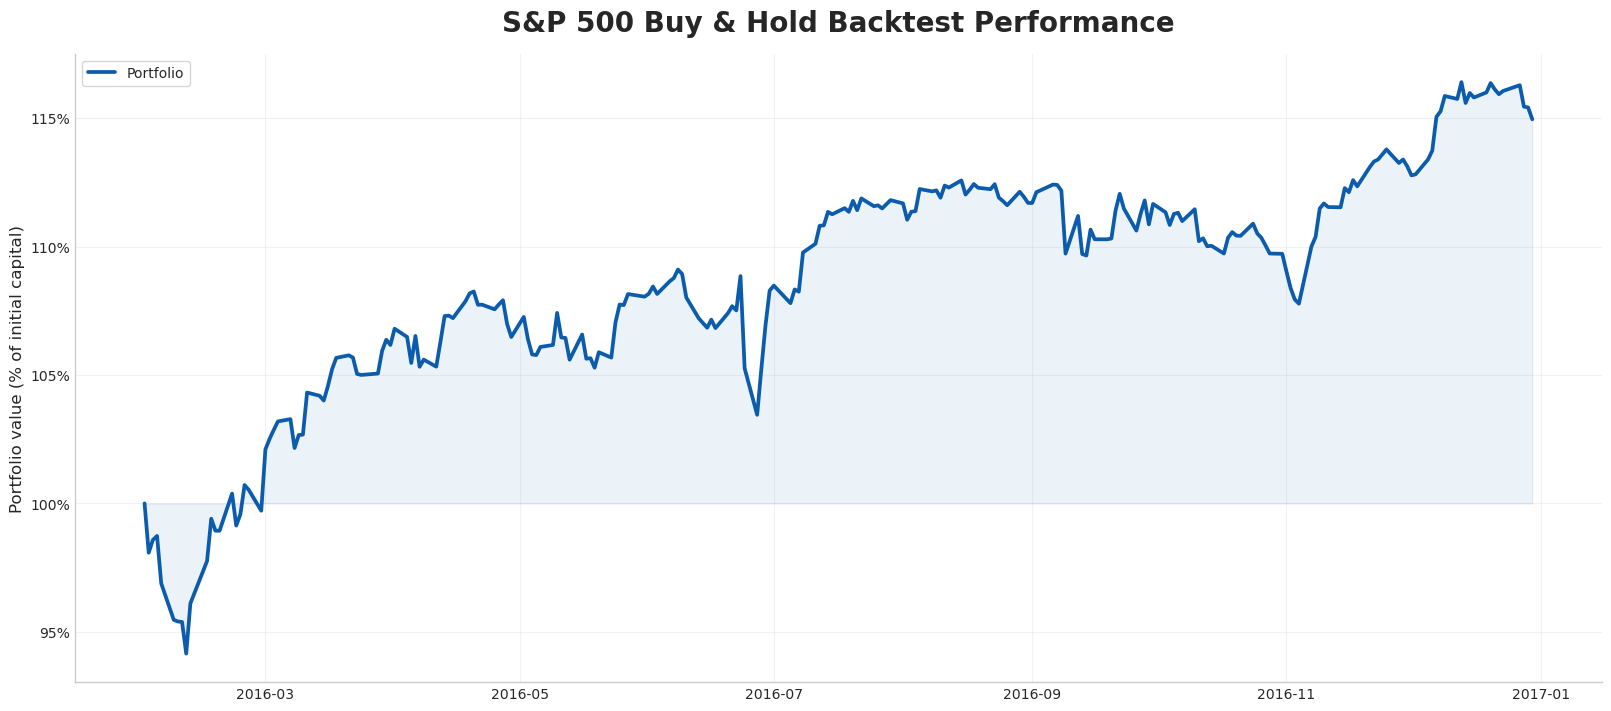

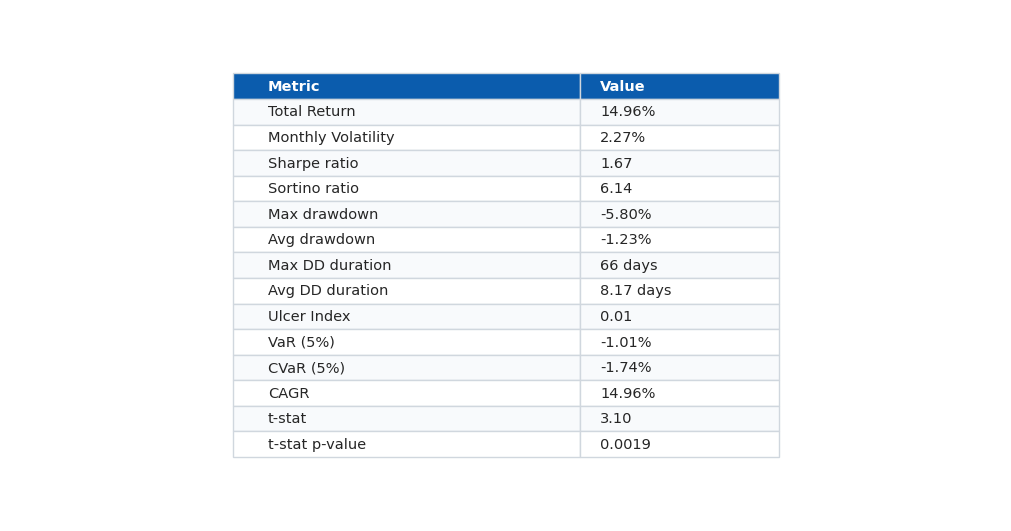

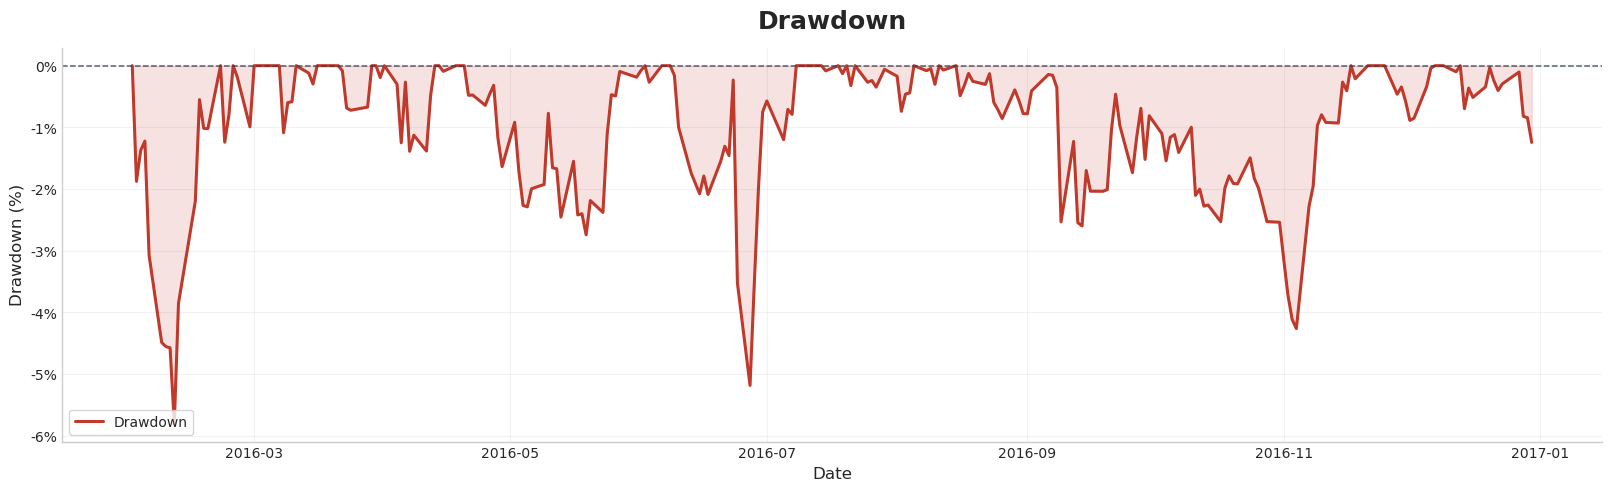

In [10]:
plt.style.use("seaborn-v0_8-whitegrid")

def as_scalar(value):
    array_value = np.asarray(value)
    if array_value.ndim == 0:
        return float(array_value)
    return float(np.nanmean(array_value))

daily_pct = daily_res["Portfolio Growth"].to_numpy() * 100
drawdown_pct = dds.to_numpy() * 100

daily_pct = pd.Series(daily_pct, index=daily_res.index)
drawdown_pct = pd.Series(drawdown_pct, index=daily_res.index)
daily_pct.iloc[0] = 100
drawdown_pct.iloc[0] = 0

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(
    daily_pct.index,
    daily_pct.values,
    color="#0B5CAD",
    linewidth=2.7,
    label="Portfolio",
)
ax.fill_between(
    daily_pct.index,
    daily_pct.values,
    100,
    color="#0B5CAD",
    alpha=0.08,
)
ax.set_title("S&P 500 Buy & Hold Backtest Performance", fontsize=20, fontweight="bold", pad=16)
ax.set_ylabel("Portfolio value (% of initial capital)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=True)

plt.show()

metrics = [
    ("Total Return", f"{as_scalar(total_portfolio_value- 1):.2%}"),
    ("Monthly Volatility", f"{as_scalar(portfolio_volatility_value):.2%}"),
    ("Sharpe ratio", f"{as_scalar(sharpe_ratio_value):.2f}"),
    ("Sortino ratio", f"{as_scalar(sortino_ratio_value):.2f}"),
    ("Max drawdown", f"{as_scalar(max_dd):.2%}"),
    ("Avg drawdown", f"{as_scalar(average_dd_depth):.2%}"),
    ("Max DD duration", f"{as_scalar(max_dd_duration):.0f} days"),
    ("Avg DD duration", f"{as_scalar(average_dd_duration):.2f} days"),
    ("Ulcer Index", f"{as_scalar(ulcer_index_value):.2f}"),
    ("VaR (5%)", f"{as_scalar(var_value):.2%}"),
    ("CVaR (5%)", f"{as_scalar(cvar_value):.2%}"),
    ("CAGR", f"{as_scalar(cagr_value):.2%}"),
    ("t-stat", f"{as_scalar(t_statistic):.2f}"),
    ("t-stat p-value", f"{as_scalar(t_p_value):.4f}"),
]

metrics_df = pd.DataFrame(metrics, columns=["Metric", "Value"])
fig_table, ax_table = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

plt.show()

fig_dd, ax_dd = plt.subplots(figsize=(16, 4.8), constrained_layout=True)
ax_dd.plot(
    drawdown_pct.index,
    drawdown_pct.values,
    color="#C0392B",
    linewidth=2.2,
    label="Drawdown",
)
ax_dd.axhline(0, color="#2F3B52", linewidth=1.1, linestyle="--", alpha=0.8)
ax_dd.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#C0392B", alpha=0.14)
ax_dd.set_title("Drawdown", fontsize=18, fontweight="bold", pad=14)
ax_dd.set_ylabel("Drawdown (%)", fontsize=12)
ax_dd.set_xlabel("Date", fontsize=12)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_dd.grid(True, which="major", alpha=0.25)
ax_dd.spines["top"].set_visible(False)
ax_dd.spines["right"].set_visible(False)
ax_dd.legend(loc="lower left", frameon=True)

plt.show()

In [11]:
# 2. Equally weighted portfolio with monthly rebalance, so 1/30 into each stock, rebalance every month

dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1
weights = np.ones(30) / 30
positions = weights * total_portfolio_value

for day in backtest_days:
    
    r = daily_stock_returns.loc[day].values 
    pnl = np.sum(positions * r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)
    positions = positions * (1 + r)
    weights = positions / total_portfolio_value

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value
        weights = np.ones(30) / 30
        positions = weights * total_portfolio_value

daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)
monthly_res = pd.DataFrame({"Portfolio Growth" : monthly_portfolio_values, "Returns" : monthly_returns}, index=backtest_months[1:])

portfolio_volatility_value = portfolio_volatility(monthly_returns)
sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
sortino_ratio_value = sortino_ratio(monthly_returns, rfr)
dds = drawdowns(daily_portfolio_values)
daily_res["Drawdowns"] = dds
max_dd = max_drawdown(dds)
average_dd_depth = average_drawdown_depth(dds)
max_dd_duration = max_drawdown_duration(daily_portfolio_values)
average_dd_duration = average_drawdown_duration(daily_portfolio_values)
ulcer_index_value = ulcer_index(dds)
var_value = var(monthly_returns)
cvar_value = cvar(monthly_returns)
cagr_value = cagr(monthly_portfolio_values[-1], len(backtest_months)/12)
t_statistic, t_p_value = t_stat(monthly_returns)
alpha, a_p_value, beta = capm_regression(monthly_returns, snp500_monthly_returns, rfr)

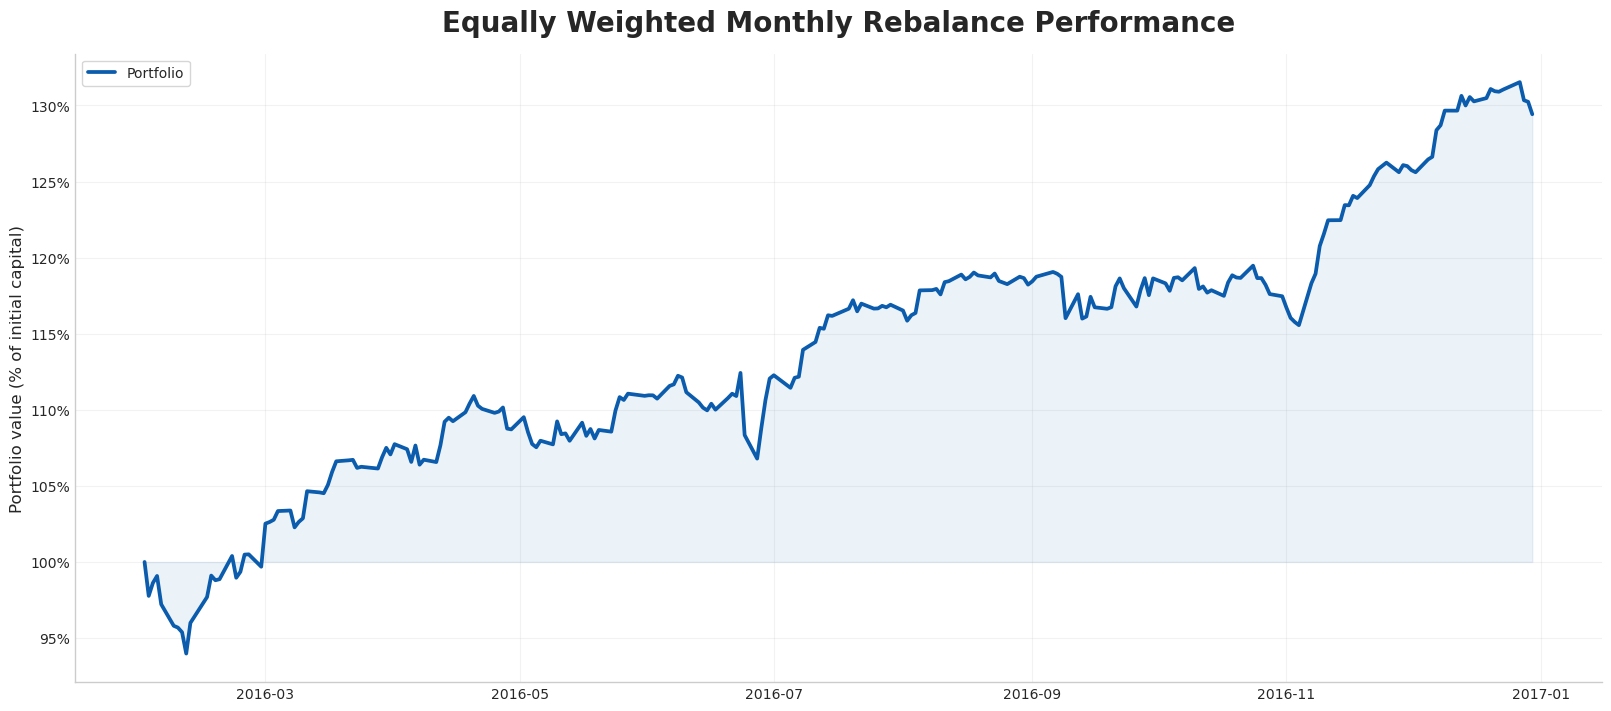

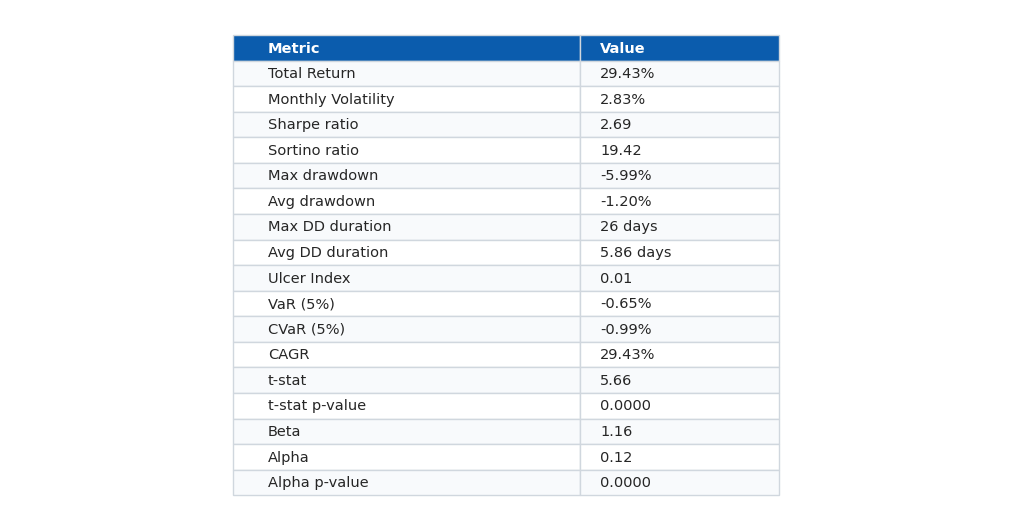

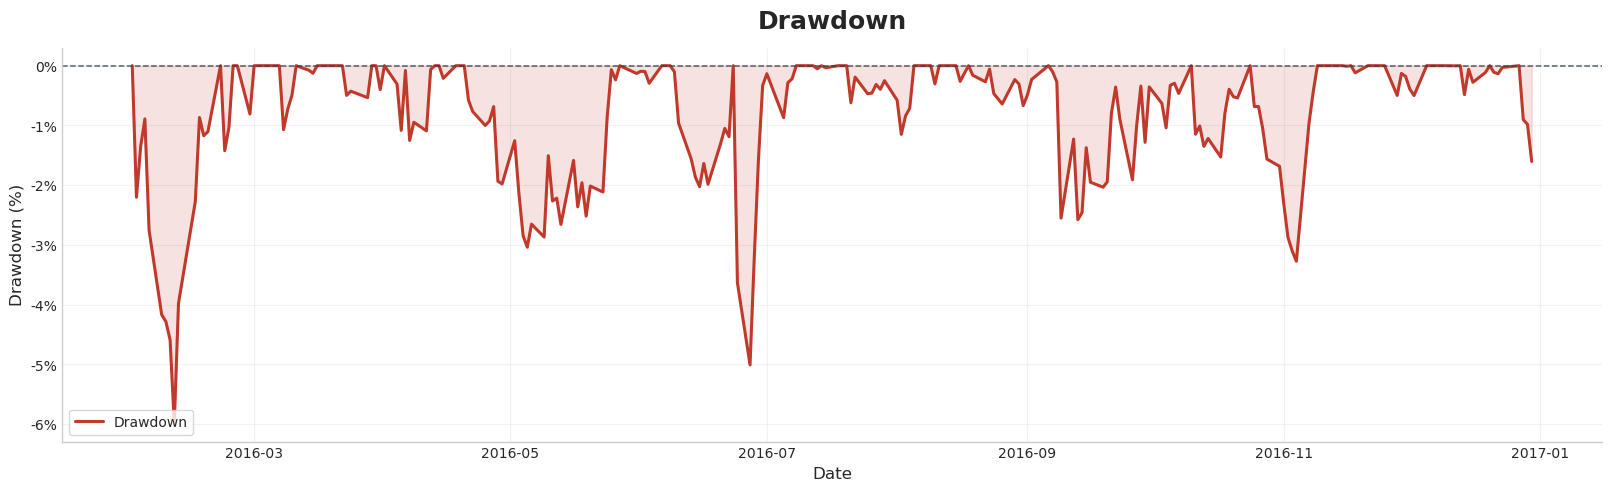

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")

def as_scalar(value):
    array_value = np.asarray(value)
    if array_value.ndim == 0:
        return float(array_value)
    return float(np.nanmean(array_value))

daily_pct = daily_res["Portfolio Growth"].to_numpy() * 100
drawdown_pct = dds.to_numpy() * 100

daily_pct = pd.Series(daily_pct, index=daily_res.index)
drawdown_pct = pd.Series(drawdown_pct, index=daily_res.index)
daily_pct.iloc[0] = 100
drawdown_pct.iloc[0] = 0

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(
    daily_pct.index,
    daily_pct.values,
    color="#0B5CAD",
    linewidth=2.7,
    label="Portfolio",
)
ax.fill_between(
    daily_pct.index,
    daily_pct.values,
    100,
    color="#0B5CAD",
    alpha=0.08,
)
ax.set_title("Equally Weighted Monthly Rebalance Performance", fontsize=20, fontweight="bold", pad=16)
ax.set_ylabel("Portfolio value (% of initial capital)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=True)

plt.show()

metrics = [
    ("Total Return", f"{as_scalar(total_portfolio_value- 1):.2%}"),
    ("Monthly Volatility", f"{as_scalar(portfolio_volatility_value):.2%}"),
    ("Sharpe ratio", f"{as_scalar(sharpe_ratio_value):.2f}"),
    ("Sortino ratio", f"{as_scalar(sortino_ratio_value):.2f}"),
    ("Max drawdown", f"{as_scalar(max_dd):.2%}"),
    ("Avg drawdown", f"{as_scalar(average_dd_depth):.2%}"),
    ("Max DD duration", f"{as_scalar(max_dd_duration):.0f} days"),
    ("Avg DD duration", f"{as_scalar(average_dd_duration):.2f} days"),
    ("Ulcer Index", f"{as_scalar(ulcer_index_value):.2f}"),
    ("VaR (5%)", f"{as_scalar(var_value):.2%}"),
    ("CVaR (5%)", f"{as_scalar(cvar_value):.2%}"),
    ("CAGR", f"{as_scalar(cagr_value):.2%}"),
    ("t-stat", f"{as_scalar(t_statistic):.2f}"),
    ("t-stat p-value", f"{as_scalar(t_p_value):.4f}"),
    ("Beta", f"{as_scalar(beta):.2f}"),
    ("Alpha", f"{as_scalar(alpha):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}")
]

metrics_df = pd.DataFrame(metrics, columns=["Metric", "Value"])
fig_table, ax_table = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

plt.show()

fig_dd, ax_dd = plt.subplots(figsize=(16, 4.8), constrained_layout=True)
ax_dd.plot(
    drawdown_pct.index,
    drawdown_pct.values,
    color="#C0392B",
    linewidth=2.2,
    label="Drawdown",
)
ax_dd.axhline(0, color="#2F3B52", linewidth=1.1, linestyle="--", alpha=0.8)
ax_dd.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#C0392B", alpha=0.14)
ax_dd.set_title("Drawdown", fontsize=18, fontweight="bold", pad=14)
ax_dd.set_ylabel("Drawdown (%)", fontsize=12)
ax_dd.set_xlabel("Date", fontsize=12)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_dd.grid(True, which="major", alpha=0.25)
ax_dd.spines["top"].set_visible(False)
ax_dd.spines["right"].set_visible(False)
ax_dd.legend(loc="lower left", frameon=True)

plt.show()

In [13]:
# 3. Black Litterman with no model predictions, so using baseline equilibrium, construct optimal portfolio

dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1
bl = BlackLitterman()
first_day = backtest[backtest.index <= backtest_days[0]].index[-1]
weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= first_day].tail(504), first_day)
positions = weights * total_portfolio_value
pred_returns = []
true_returns = []

for day in backtest_days:

    r = daily_stock_returns.loc[day].values 
    pnl = np.sum(positions * r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)
    positions = positions * (1 + r)
    weights = positions / total_portfolio_value

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value
        pred_returns.append(expected_returns)
        true_returns.append(monthly_stock_returns.loc[day].values)
        weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= day].tail(504), day)
        positions = weights * total_portfolio_value


pred_returns = np.stack([np.squeeze(p) for p in pred_returns])
true_returns = np.stack([np.squeeze(t) for t in true_returns])

daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)
monthly_res = pd.DataFrame({"Portfolio Growth" : monthly_portfolio_values, "Returns" : monthly_returns}, index=backtest_months[1:])

portfolio_volatility_value = portfolio_volatility(monthly_returns)
sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
sortino_ratio_value = sortino_ratio(monthly_returns, rfr)
dds = drawdowns(daily_portfolio_values)
daily_res["Drawdowns"] = dds
max_dd = max_drawdown(dds)
average_dd_depth = average_drawdown_depth(dds)
max_dd_duration = max_drawdown_duration(daily_portfolio_values)
average_dd_duration = average_drawdown_duration(daily_portfolio_values)
ulcer_index_value = ulcer_index(dds)
var_value = var(monthly_returns)
cvar_value = cvar(monthly_returns)
cagr_value = cagr(monthly_portfolio_values[-1], len(backtest_months)/12)
t_statistic, t_p_value = t_stat(monthly_returns)
alpha, a_p_value, beta = capm_regression(monthly_returns, snp500_monthly_returns, rfr)
bl_IC, bl_MSE, bl_DA, bl_U2 = bl_ER_precision(pred_returns, true_returns)

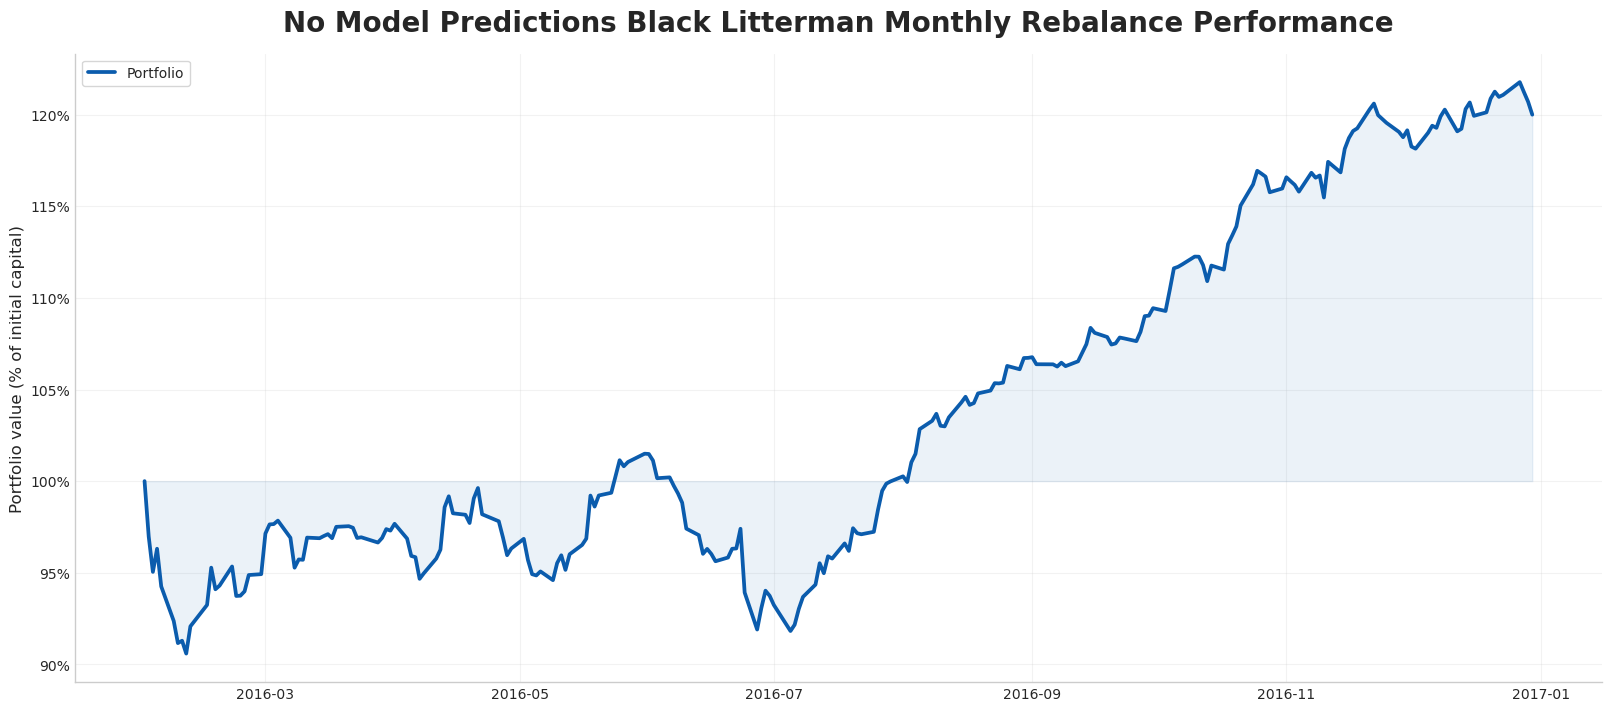

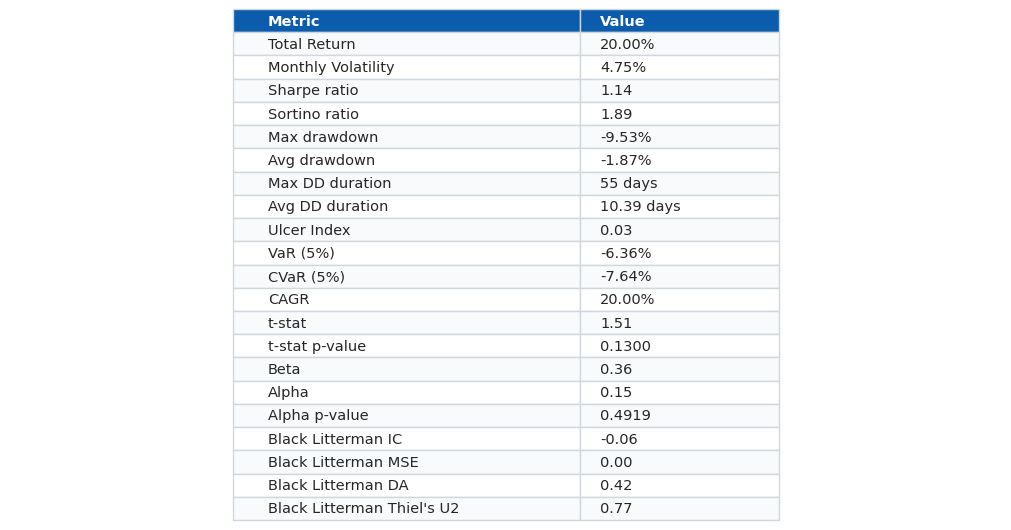

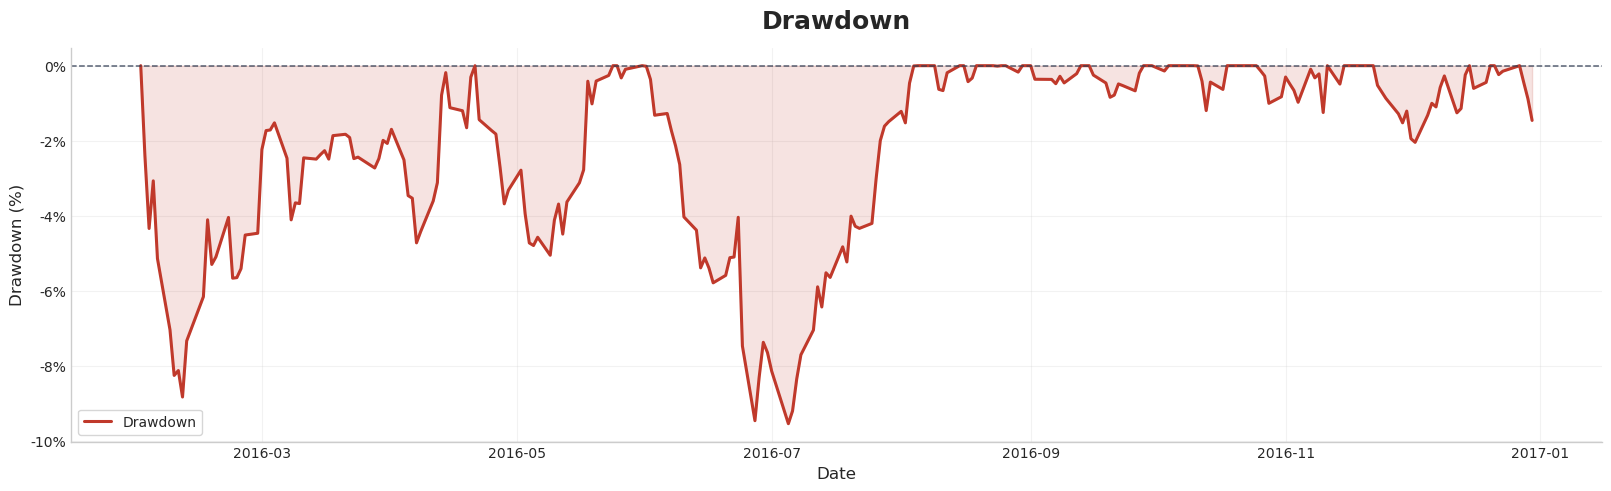

In [14]:
plt.style.use("seaborn-v0_8-whitegrid")

def as_scalar(value):
    array_value = np.asarray(value)
    if array_value.ndim == 0:
        return float(array_value)
    return float(np.nanmean(array_value))

daily_pct = daily_res["Portfolio Growth"].to_numpy() * 100
drawdown_pct = dds.to_numpy() * 100

daily_pct = pd.Series(daily_pct, index=daily_res.index)
drawdown_pct = pd.Series(drawdown_pct, index=daily_res.index)
daily_pct.iloc[0] = 100
drawdown_pct.iloc[0] = 0

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(
    daily_pct.index,
    daily_pct.values,
    color="#0B5CAD",
    linewidth=2.7,
    label="Portfolio",
)
ax.fill_between(
    daily_pct.index,
    daily_pct.values,
    100,
    color="#0B5CAD",
    alpha=0.08,
)
ax.set_title("No Model Predictions Black Litterman Monthly Rebalance Performance", fontsize=20, fontweight="bold", pad=16)
ax.set_ylabel("Portfolio value (% of initial capital)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=True)

plt.show()

metrics = [
    ("Total Return", f"{as_scalar(total_portfolio_value- 1):.2%}"),
    ("Monthly Volatility", f"{as_scalar(portfolio_volatility_value):.2%}"),
    ("Sharpe ratio", f"{as_scalar(sharpe_ratio_value):.2f}"),
    ("Sortino ratio", f"{as_scalar(sortino_ratio_value):.2f}"),
    ("Max drawdown", f"{as_scalar(max_dd):.2%}"),
    ("Avg drawdown", f"{as_scalar(average_dd_depth):.2%}"),
    ("Max DD duration", f"{as_scalar(max_dd_duration):.0f} days"),
    ("Avg DD duration", f"{as_scalar(average_dd_duration):.2f} days"),
    ("Ulcer Index", f"{as_scalar(ulcer_index_value):.2f}"),
    ("VaR (5%)", f"{as_scalar(var_value):.2%}"),
    ("CVaR (5%)", f"{as_scalar(cvar_value):.2%}"),
    ("CAGR", f"{as_scalar(cagr_value):.2%}"),
    ("t-stat", f"{as_scalar(t_statistic):.2f}"),
    ("t-stat p-value", f"{as_scalar(t_p_value):.4f}"),
    ("Beta", f"{as_scalar(beta):.2f}"),
    ("Alpha", f"{as_scalar(alpha):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}"),
    ("Black Litterman IC", f"{as_scalar(bl_IC):.2f}"),
    ("Black Litterman MSE", f"{as_scalar(bl_MSE):.2f}"),
    ("Black Litterman DA", f"{as_scalar(bl_DA):.2f}"),
    ("Black Litterman Thiel's U2", f"{as_scalar(bl_U2):.2f}")
]

metrics_df = pd.DataFrame(metrics, columns=["Metric", "Value"])
fig_table, ax_table = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

plt.show()

fig_dd, ax_dd = plt.subplots(figsize=(16, 4.8), constrained_layout=True)
ax_dd.plot(
    drawdown_pct.index,
    drawdown_pct.values,
    color="#C0392B",
    linewidth=2.2,
    label="Drawdown",
)
ax_dd.axhline(0, color="#2F3B52", linewidth=1.1, linestyle="--", alpha=0.8)
ax_dd.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#C0392B", alpha=0.14)
ax_dd.set_title("Drawdown", fontsize=18, fontweight="bold", pad=14)
ax_dd.set_ylabel("Drawdown (%)", fontsize=12)
ax_dd.set_xlabel("Date", fontsize=12)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_dd.grid(True, which="major", alpha=0.25)
ax_dd.spines["top"].set_visible(False)
ax_dd.spines["right"].set_visible(False)
ax_dd.legend(loc="lower left", frameon=True)

plt.show()

In [15]:
# 4. Black Litterman with random predictions, a monte carlo baseline, then construct optimal portfolio

dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1
bl = BlackLitterman()
first_day = backtest[backtest.index <= backtest_days[0]].index[-1]
preds = pd.DataFrame({"Ticker": daily_stock_returns.columns})
guess = np.random.rand(30)
preds["Predictions"] = guess
# will not calculate rolling IC for confidence factor for random guesses as it will be too noisy, use a stable constant 1
weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= first_day].tail(504), first_day, preds=preds)
positions = weights * total_portfolio_value
pred_returns = []
true_returns = []

for day in backtest_days:

    r = daily_stock_returns.loc[day].values 
    pnl = np.sum(positions * r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)
    positions = positions * (1 + r)
    weights = positions / total_portfolio_value

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value
        pred_returns.append(expected_returns)
        true_returns.append(monthly_stock_returns.loc[day].values)
        guess = np.random.rand(30)
        preds["Predictions"] = guess
        weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= day].tail(504), day, preds=preds)
        positions = weights * total_portfolio_value

pred_returns = np.stack([np.squeeze(p) for p in pred_returns])
true_returns = np.stack([np.squeeze(t) for t in true_returns])

daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)
monthly_res = pd.DataFrame({"Portfolio Growth" : monthly_portfolio_values, "Returns" : monthly_returns}, index=backtest_months[1:])

portfolio_volatility_value = portfolio_volatility(monthly_returns)
sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
sortino_ratio_value = sortino_ratio(monthly_returns, rfr)
dds = drawdowns(daily_portfolio_values)
daily_res["Drawdowns"] = dds
max_dd = max_drawdown(dds)
average_dd_depth = average_drawdown_depth(dds)
max_dd_duration = max_drawdown_duration(daily_portfolio_values)
average_dd_duration = average_drawdown_duration(daily_portfolio_values)
ulcer_index_value = ulcer_index(dds)
var_value = var(monthly_returns)
cvar_value = cvar(monthly_returns)
cagr_value = cagr(monthly_portfolio_values[-1], len(backtest_months)/12)
t_statistic, t_p_value = t_stat(monthly_returns)
alpha, a_p_value, beta = capm_regression(monthly_returns, snp500_monthly_returns, rfr)
bl_IC, bl_MSE, bl_DA, bl_U2 = bl_ER_precision(pred_returns, true_returns)

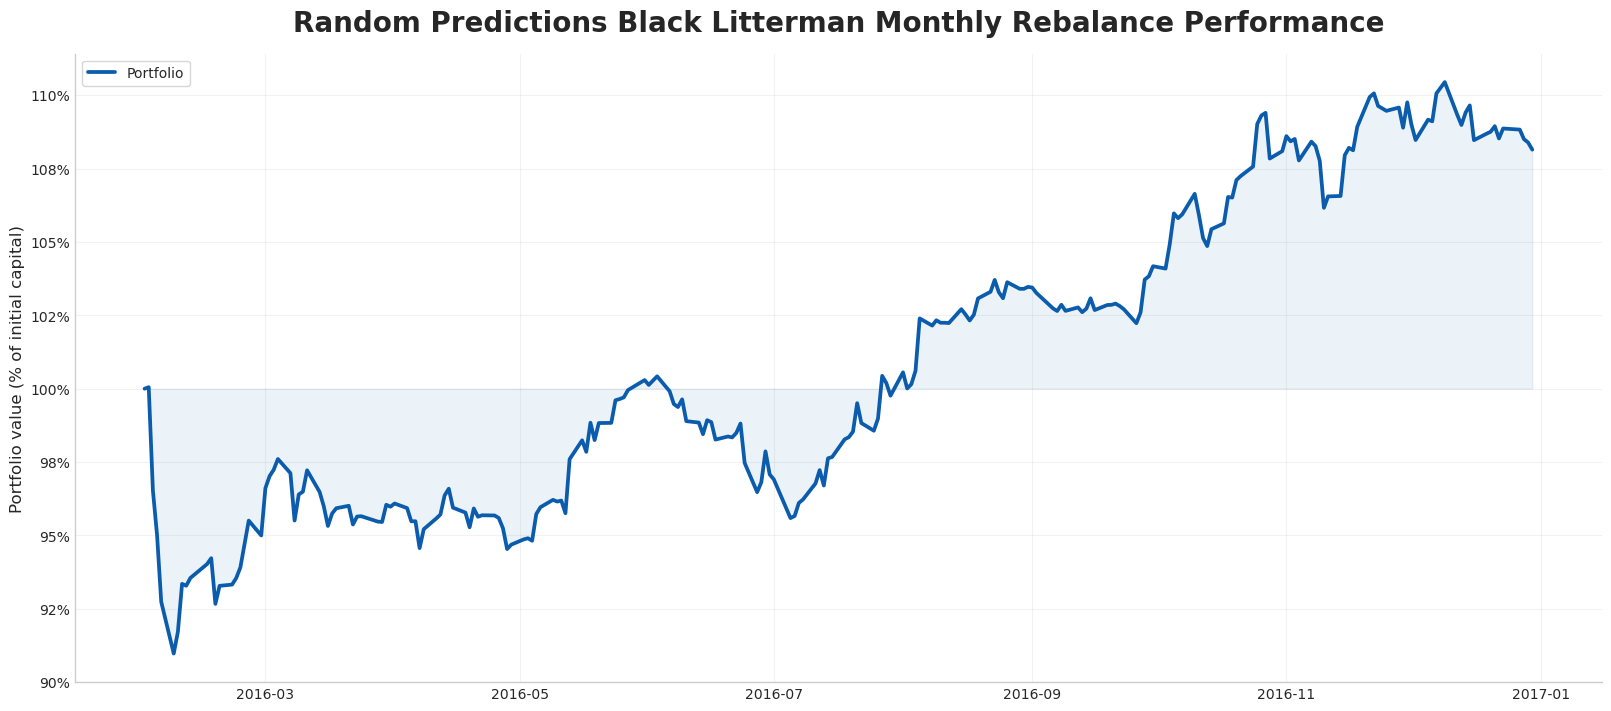

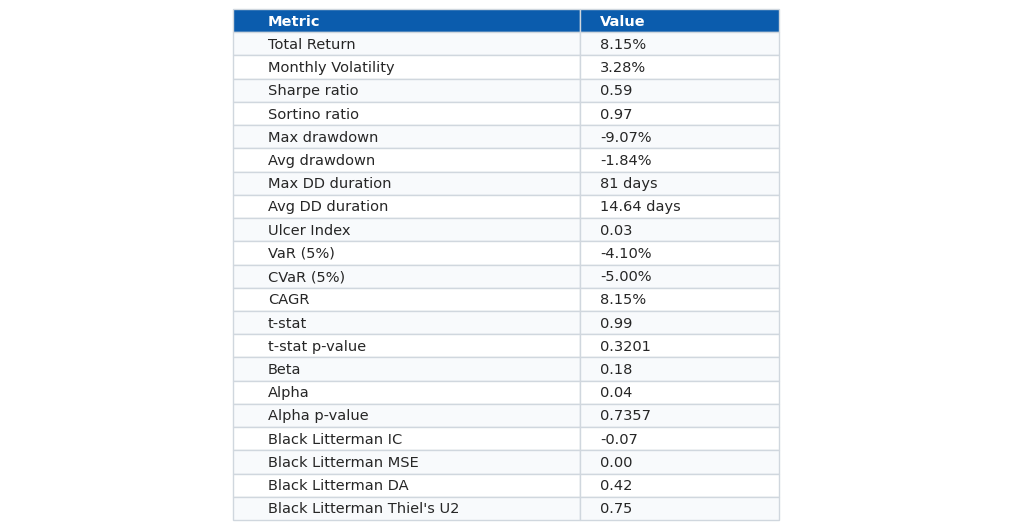

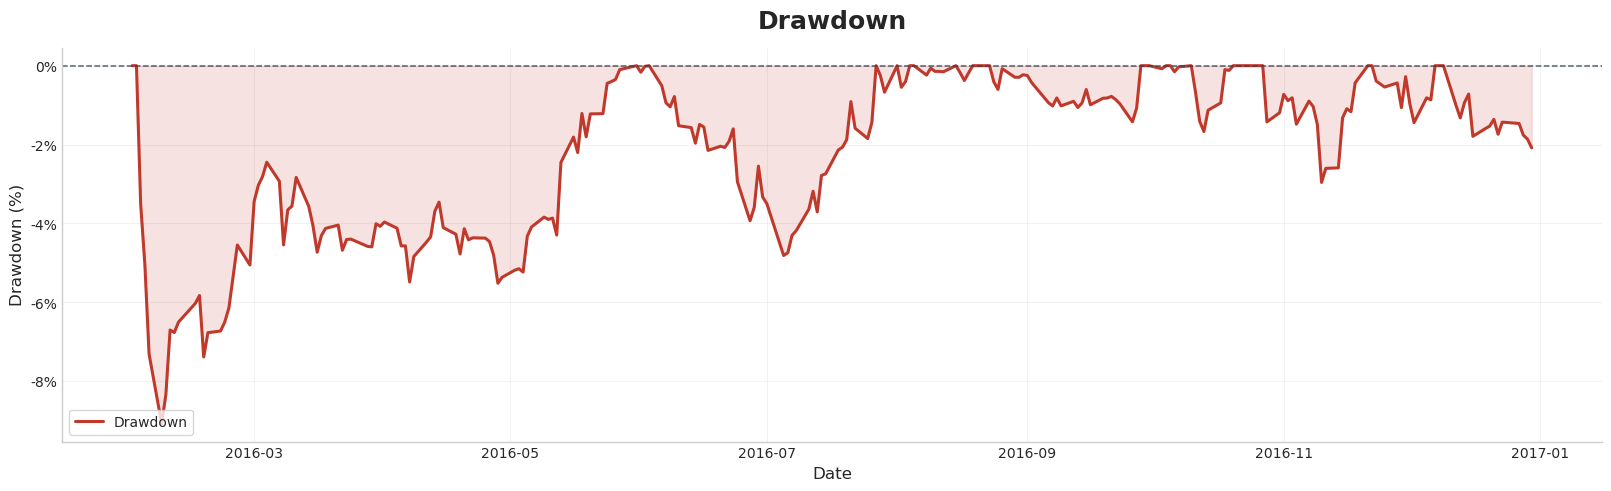

In [16]:
plt.style.use("seaborn-v0_8-whitegrid")

def as_scalar(value):
    array_value = np.asarray(value)
    if array_value.ndim == 0:
        return float(array_value)
    return float(np.nanmean(array_value))

daily_pct = daily_res["Portfolio Growth"].to_numpy() * 100
drawdown_pct = dds.to_numpy() * 100

daily_pct = pd.Series(daily_pct, index=daily_res.index)
drawdown_pct = pd.Series(drawdown_pct, index=daily_res.index)
daily_pct.iloc[0] = 100
drawdown_pct.iloc[0] = 0

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(
    daily_pct.index,
    daily_pct.values,
    color="#0B5CAD",
    linewidth=2.7,
    label="Portfolio",
)
ax.fill_between(
    daily_pct.index,
    daily_pct.values,
    100,
    color="#0B5CAD",
    alpha=0.08,
)
ax.set_title("Random Predictions Black Litterman Monthly Rebalance Performance", fontsize=20, fontweight="bold", pad=16)
ax.set_ylabel("Portfolio value (% of initial capital)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=True)

plt.show()

metrics = [
    ("Total Return", f"{as_scalar(total_portfolio_value- 1):.2%}"),
    ("Monthly Volatility", f"{as_scalar(portfolio_volatility_value):.2%}"),
    ("Sharpe ratio", f"{as_scalar(sharpe_ratio_value):.2f}"),
    ("Sortino ratio", f"{as_scalar(sortino_ratio_value):.2f}"),
    ("Max drawdown", f"{as_scalar(max_dd):.2%}"),
    ("Avg drawdown", f"{as_scalar(average_dd_depth):.2%}"),
    ("Max DD duration", f"{as_scalar(max_dd_duration):.0f} days"),
    ("Avg DD duration", f"{as_scalar(average_dd_duration):.2f} days"),
    ("Ulcer Index", f"{as_scalar(ulcer_index_value):.2f}"),
    ("VaR (5%)", f"{as_scalar(var_value):.2%}"),
    ("CVaR (5%)", f"{as_scalar(cvar_value):.2%}"),
    ("CAGR", f"{as_scalar(cagr_value):.2%}"),
    ("t-stat", f"{as_scalar(t_statistic):.2f}"),
    ("t-stat p-value", f"{as_scalar(t_p_value):.4f}"),
    ("Beta", f"{as_scalar(beta):.2f}"),
    ("Alpha", f"{as_scalar(alpha):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}"),
    ("Black Litterman IC", f"{as_scalar(bl_IC):.2f}"),
    ("Black Litterman MSE", f"{as_scalar(bl_MSE):.2f}"),
    ("Black Litterman DA", f"{as_scalar(bl_DA):.2f}"),
    ("Black Litterman Thiel's U2", f"{as_scalar(bl_U2):.2f}")
]

metrics_df = pd.DataFrame(metrics, columns=["Metric", "Value"])
fig_table, ax_table = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

plt.show()

fig_dd, ax_dd = plt.subplots(figsize=(16, 4.8), constrained_layout=True)
ax_dd.plot(
    drawdown_pct.index,
    drawdown_pct.values,
    color="#C0392B",
    linewidth=2.2,
    label="Drawdown",
)
ax_dd.axhline(0, color="#2F3B52", linewidth=1.1, linestyle="--", alpha=0.8)
ax_dd.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#C0392B", alpha=0.14)
ax_dd.set_title("Drawdown", fontsize=18, fontweight="bold", pad=14)
ax_dd.set_ylabel("Drawdown (%)", fontsize=12)
ax_dd.set_xlabel("Date", fontsize=12)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_dd.grid(True, which="major", alpha=0.25)
ax_dd.spines["top"].set_visible(False)
ax_dd.spines["right"].set_visible(False)
ax_dd.legend(loc="lower left", frameon=True)

plt.show()

In [21]:
# finally move onto real backtest, with real model
# will use lin model again for simplicity and speed

dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1
first_day = backtest[backtest.index <= backtest_days[0]].index[-1]
model = LinearRegression(n_jobs=-1)
features = [c for c in backtest.columns if c not in ["Ticker", "Target"]]
model.fit(backtest[backtest.index < first_day][features].to_numpy(), backtest[backtest.index < first_day]["Target"].to_numpy())
bl = BlackLitterman()
preds = pd.DataFrame({"Ticker": daily_stock_returns.columns})
pred = model.predict(backtest.loc[first_day][features].values)
preds["Predictions"] = pred
pred_z_scores = [pred]
true_z_scores = [backtest.loc[first_day]["Target"].to_numpy()]
# here we will calculate rolling IC for confidence factor (we have changed how we calculate confidence factor from the original backtest notebook
# but we use last 6 months, so first 2 months we don't have enough data for std of IC
# so we use 1 like with guessing backtest, from then on out we use normal rolling IC confidence factor
weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= first_day].tail(504), first_day, preds=preds)
positions = weights * total_portfolio_value
pred_returns = []
true_returns = []

for day in backtest_days:

    r = daily_stock_returns.loc[day].values 
    pnl = np.sum(positions * r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)
    positions = positions * (1 + r)
    weights = positions / total_portfolio_value

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value
        pred_returns.append(expected_returns)
        true_returns.append(monthly_stock_returns.loc[day].values)
        model.fit(backtest[backtest.index < day][features].to_numpy(), backtest[backtest.index < day]["Target"].to_numpy())
        pred = model.predict(backtest.loc[day][features].values)
        preds["Predictions"] = pred
        weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= day].tail(504), day, preds=preds, y_pred=pred_z_scores, y_true=true_z_scores)
        positions = weights * total_portfolio_value
        pred_z_scores.append(pred)
        true_z_scores.append(backtest.loc[day]["Target"].to_numpy())

pred_returns = np.stack([np.squeeze(p) for p in pred_returns])
true_returns = np.stack([np.squeeze(t) for t in true_returns])

daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)
monthly_res = pd.DataFrame({"Portfolio Growth" : monthly_portfolio_values, "Returns" : monthly_returns}, index=backtest_months[1:])

portfolio_volatility_value = portfolio_volatility(monthly_returns)
sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
sortino_ratio_value = sortino_ratio(monthly_returns, rfr)
dds = drawdowns(daily_portfolio_values)
daily_res["Drawdowns"] = dds
max_dd = max_drawdown(dds)
average_dd_depth = average_drawdown_depth(dds)
max_dd_duration = max_drawdown_duration(daily_portfolio_values)
average_dd_duration = average_drawdown_duration(daily_portfolio_values)
ulcer_index_value = ulcer_index(dds)
var_value = var(monthly_returns)
cvar_value = cvar(monthly_returns)
cagr_value = cagr(monthly_portfolio_values[-1], len(backtest_months)/12)
t_statistic, t_p_value = t_stat(monthly_returns)
alpha, a_p_value, beta = capm_regression(monthly_returns, snp500_monthly_returns, rfr)
bl_IC, bl_MSE, bl_DA, bl_U2 = bl_ER_precision(pred_returns, true_returns)
model_IC, model_MSE, model_DA = model_precision(pred_z_scores, true_z_scores)

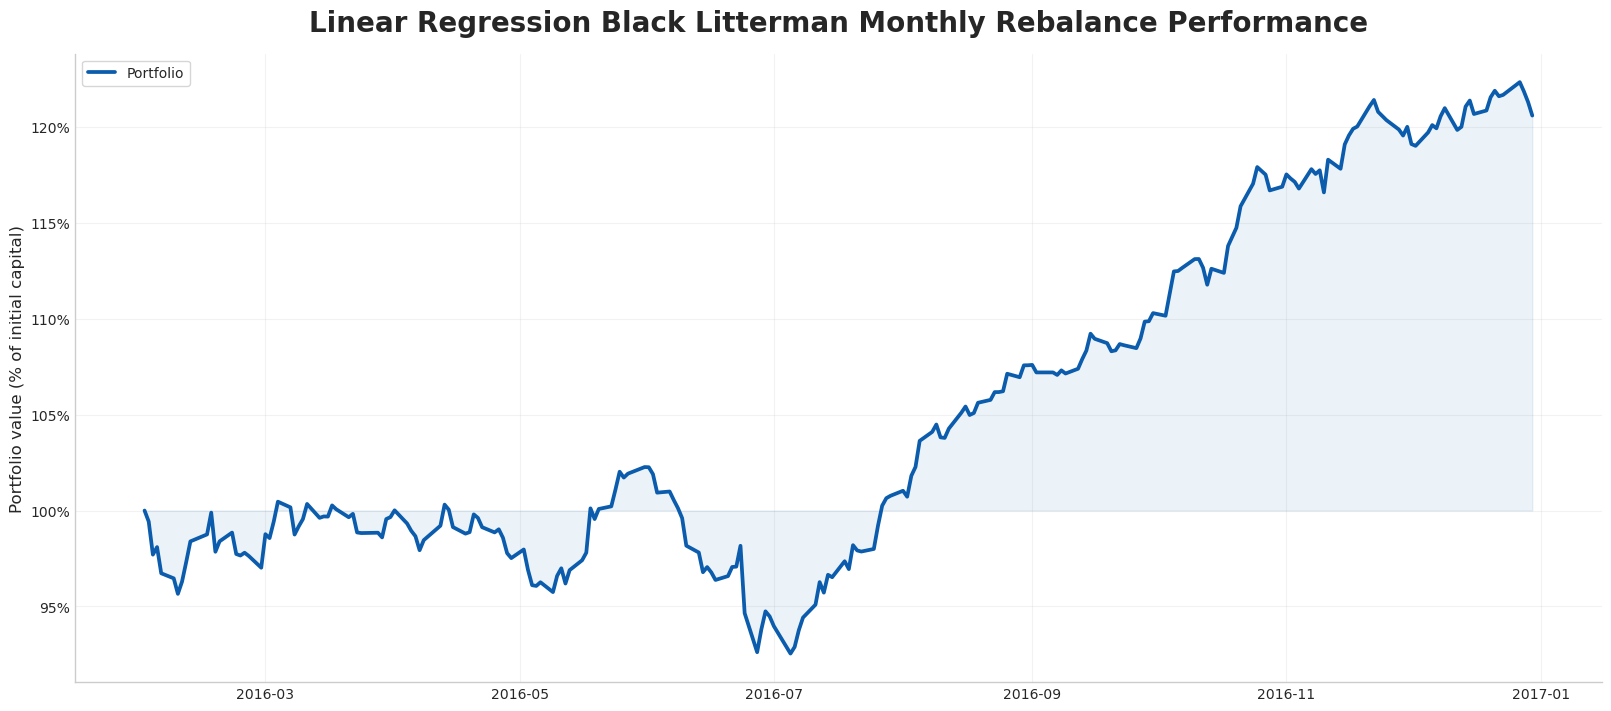

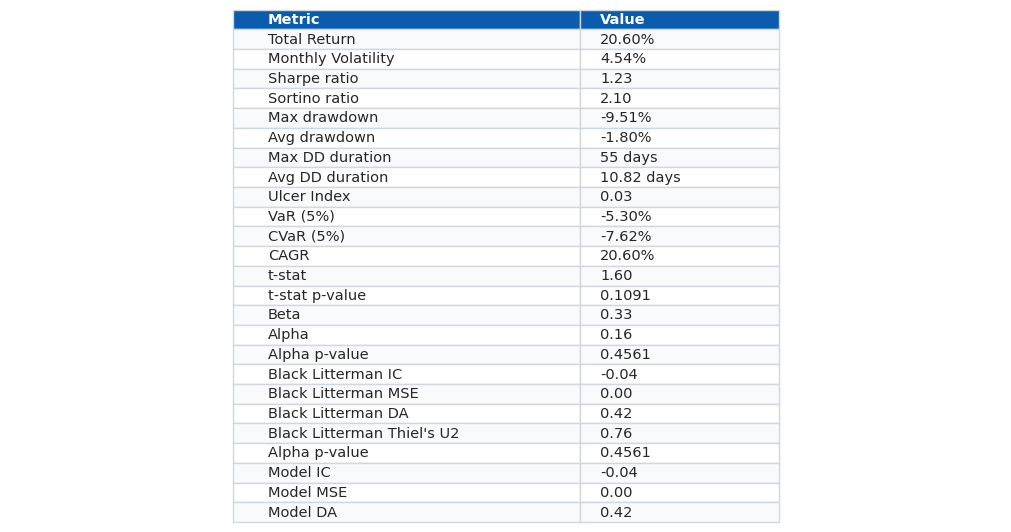

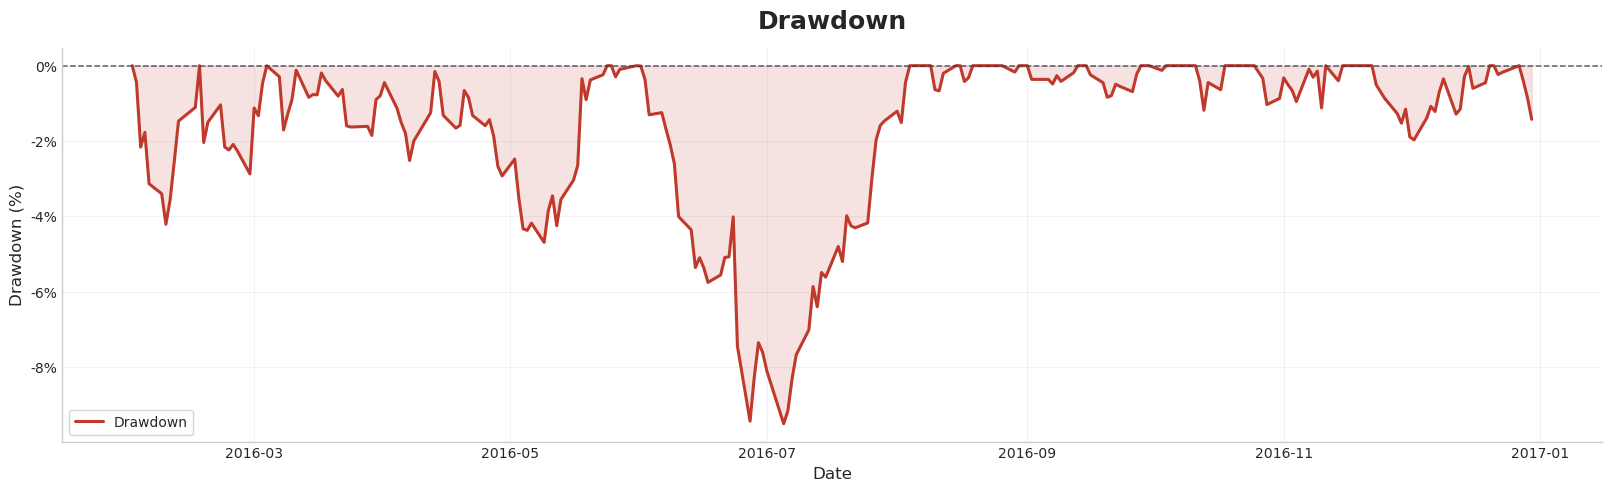

In [22]:
plt.style.use("seaborn-v0_8-whitegrid")

def as_scalar(value):
    array_value = np.asarray(value)
    if array_value.ndim == 0:
        return float(array_value)
    return float(np.nanmean(array_value))

daily_pct = daily_res["Portfolio Growth"].to_numpy() * 100
drawdown_pct = dds.to_numpy() * 100

daily_pct = pd.Series(daily_pct, index=daily_res.index)
drawdown_pct = pd.Series(drawdown_pct, index=daily_res.index)
daily_pct.iloc[0] = 100
drawdown_pct.iloc[0] = 0

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(
    daily_pct.index,
    daily_pct.values,
    color="#0B5CAD",
    linewidth=2.7,
    label="Portfolio",
)
ax.fill_between(
    daily_pct.index,
    daily_pct.values,
    100,
    color="#0B5CAD",
    alpha=0.08,
)
ax.set_title("Linear Regression Black Litterman Monthly Rebalance Performance", fontsize=20, fontweight="bold", pad=16)
ax.set_ylabel("Portfolio value (% of initial capital)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=True)

plt.show()

metrics = [
    ("Total Return", f"{as_scalar(total_portfolio_value- 1):.2%}"),
    ("Monthly Volatility", f"{as_scalar(portfolio_volatility_value):.2%}"),
    ("Sharpe ratio", f"{as_scalar(sharpe_ratio_value):.2f}"),
    ("Sortino ratio", f"{as_scalar(sortino_ratio_value):.2f}"),
    ("Max drawdown", f"{as_scalar(max_dd):.2%}"),
    ("Avg drawdown", f"{as_scalar(average_dd_depth):.2%}"),
    ("Max DD duration", f"{as_scalar(max_dd_duration):.0f} days"),
    ("Avg DD duration", f"{as_scalar(average_dd_duration):.2f} days"),
    ("Ulcer Index", f"{as_scalar(ulcer_index_value):.2f}"),
    ("VaR (5%)", f"{as_scalar(var_value):.2%}"),
    ("CVaR (5%)", f"{as_scalar(cvar_value):.2%}"),
    ("CAGR", f"{as_scalar(cagr_value):.2%}"),
    ("t-stat", f"{as_scalar(t_statistic):.2f}"),
    ("t-stat p-value", f"{as_scalar(t_p_value):.4f}"),
    ("Beta", f"{as_scalar(beta):.2f}"),
    ("Alpha", f"{as_scalar(alpha):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}"),
    ("Black Litterman IC", f"{as_scalar(bl_IC):.2f}"),
    ("Black Litterman MSE", f"{as_scalar(bl_MSE):.2f}"),
    ("Black Litterman DA", f"{as_scalar(bl_DA):.2f}"),
    ("Black Litterman Thiel's U2", f"{as_scalar(bl_U2):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}"),
    ("Model IC", f"{as_scalar(bl_IC):.2f}"),
    ("Model MSE", f"{as_scalar(bl_MSE):.2f}"),
    ("Model DA", f"{as_scalar(bl_DA):.2f}")
]

metrics_df = pd.DataFrame(metrics, columns=["Metric", "Value"])
fig_table, ax_table = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

plt.show()

fig_dd, ax_dd = plt.subplots(figsize=(16, 4.8), constrained_layout=True)
ax_dd.plot(
    drawdown_pct.index,
    drawdown_pct.values,
    color="#C0392B",
    linewidth=2.2,
    label="Drawdown",
)
ax_dd.axhline(0, color="#2F3B52", linewidth=1.1, linestyle="--", alpha=0.8)
ax_dd.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#C0392B", alpha=0.14)
ax_dd.set_title("Drawdown", fontsize=18, fontweight="bold", pad=14)
ax_dd.set_ylabel("Drawdown (%)", fontsize=12)
ax_dd.set_xlabel("Date", fontsize=12)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_dd.grid(True, which="major", alpha=0.25)
ax_dd.spines["top"].set_visible(False)
ax_dd.spines["right"].set_visible(False)
ax_dd.legend(loc="lower left", frameon=True)

plt.show()

In [25]:
first_day

Timestamp('2016-01-29 00:00:00')

In [26]:
# backtest with hyperparam tuning
# use lasso for speed

dates = []
daily_returns = []
monthly_returns = []
daily_portfolio_values = []
monthly_portfolio_values = []
total_portfolio_value = 1
monthly_start_value = 1
first_day = backtest[backtest.index <= backtest_days[0]].index[-1]
prev_day = first_day - pd.Timedelta(days=1)
model = Lasso(max_iter=1000, tol=1e-4, selection="random")
grid = RollingGridSearch(model, param_grid = {'alpha': np.logspace(-4,-1,10)}, min_train_size=12, verbose=0)
X, y = dl.load_dataset("hpt", prev_day)
grid.fit(X,y)
features = [c for c in backtest.columns if c not in ["Ticker", "Target"]]
bl = BlackLitterman()
preds = pd.DataFrame({"Ticker": daily_stock_returns.columns})
pred = grid.predict(backtest.loc[first_day][features].values)
preds["Predictions"] = pred
pred_z_scores = [pred]
true_z_scores = [backtest.loc[first_day]["Target"].to_numpy()]
weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= first_day].tail(504), first_day, preds=preds)
positions = weights * total_portfolio_value
pred_returns = []
true_returns = []

for day in backtest_days:

    r = daily_stock_returns.loc[day].values 
    pnl = np.sum(positions * r)
    portfolio_return = pnl / total_portfolio_value
    daily_returns.append(portfolio_return)
    total_portfolio_value += pnl
    daily_portfolio_values.append(total_portfolio_value)
    positions = positions * (1 + r)
    weights = positions / total_portfolio_value

    if day in backtest_months:
        dates.append(day)
        monthly_return = (total_portfolio_value / monthly_start_value) - 1
        monthly_returns.append(monthly_return)
        monthly_portfolio_values.append(total_portfolio_value)
        monthly_start_value = total_portfolio_value
        pred_returns.append(expected_returns)
        true_returns.append(monthly_stock_returns.loc[day].values)
        prev_day = day - pd.Timedelta(days=1)
        X, y = dl.load_dataset("hpt", prev_day)
        grid.fit(X,y)
        pred = grid.predict(backtest.loc[day][features].values)
        preds["Predictions"] = pred
        weights, expected_returns = bl.optimize_portfolio(daily_stock_returns[daily_stock_returns.index <= day].tail(504), day, preds=preds, y_pred=pred_z_scores, y_true=true_z_scores)
        positions = weights * total_portfolio_value
        pred_z_scores.append(pred)
        true_z_scores.append(backtest.loc[day]["Target"].to_numpy())

pred_returns = np.stack([np.squeeze(p) for p in pred_returns])
true_returns = np.stack([np.squeeze(t) for t in true_returns])

daily_res = pd.DataFrame({"Portfolio Growth" : daily_portfolio_values, "Returns" : daily_returns}, index=backtest_days)
monthly_res = pd.DataFrame({"Portfolio Growth" : monthly_portfolio_values, "Returns" : monthly_returns}, index=backtest_months[1:])

portfolio_volatility_value = portfolio_volatility(monthly_returns)
sharpe_ratio_value = sharpe_ratio(monthly_returns, rfr)
sortino_ratio_value = sortino_ratio(monthly_returns, rfr)
dds = drawdowns(daily_portfolio_values)
daily_res["Drawdowns"] = dds
max_dd = max_drawdown(dds)
average_dd_depth = average_drawdown_depth(dds)
max_dd_duration = max_drawdown_duration(daily_portfolio_values)
average_dd_duration = average_drawdown_duration(daily_portfolio_values)
ulcer_index_value = ulcer_index(dds)
var_value = var(monthly_returns)
cvar_value = cvar(monthly_returns)
cagr_value = cagr(monthly_portfolio_values[-1], len(backtest_months)/12)
t_statistic, t_p_value = t_stat(monthly_returns)
alpha, a_p_value, beta = capm_regression(monthly_returns, snp500_monthly_returns, rfr)
bl_IC, bl_MSE, bl_DA, bl_U2 = bl_ER_precision(pred_returns, true_returns)
model_IC, model_MSE, model_DA = model_precision(pred_z_scores, true_z_scores)

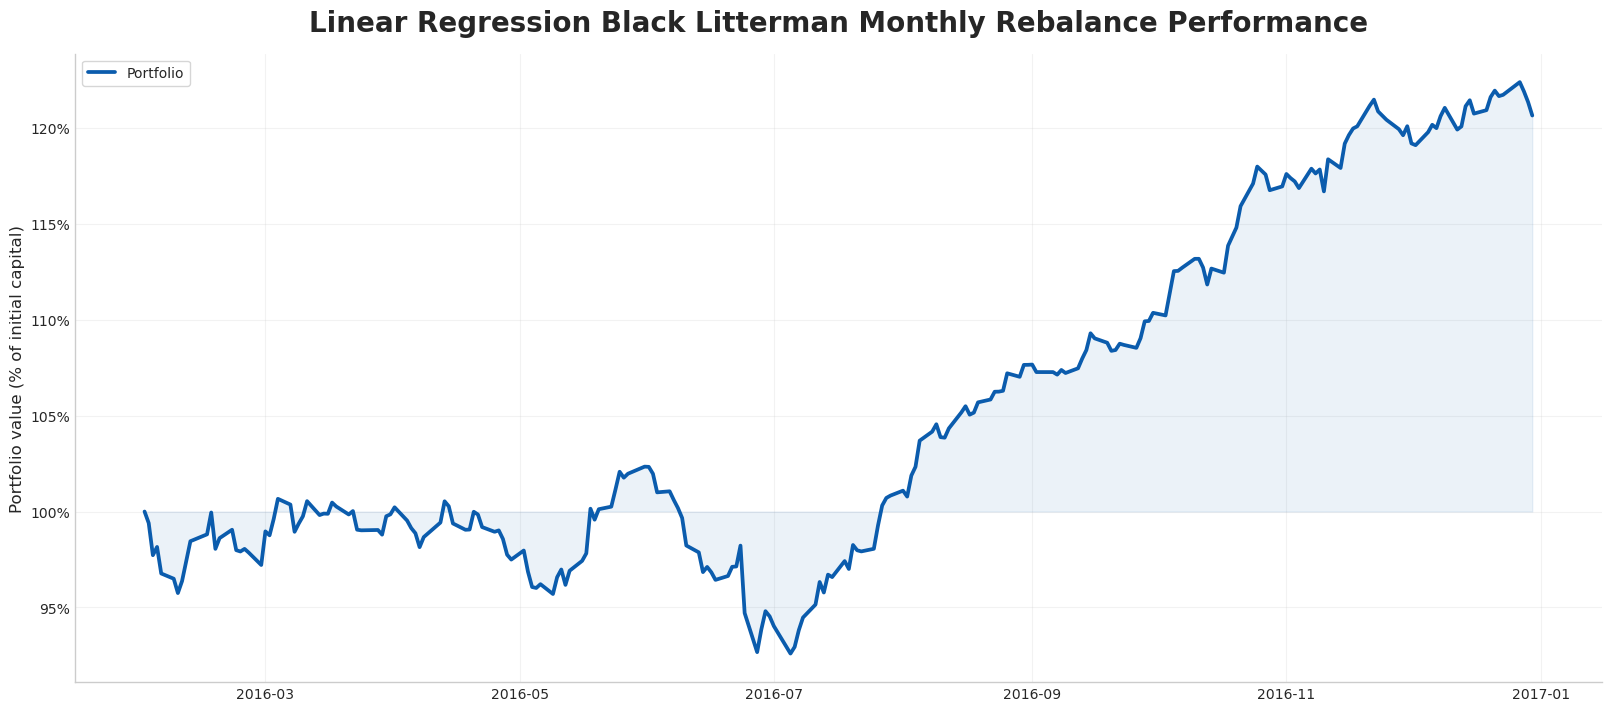

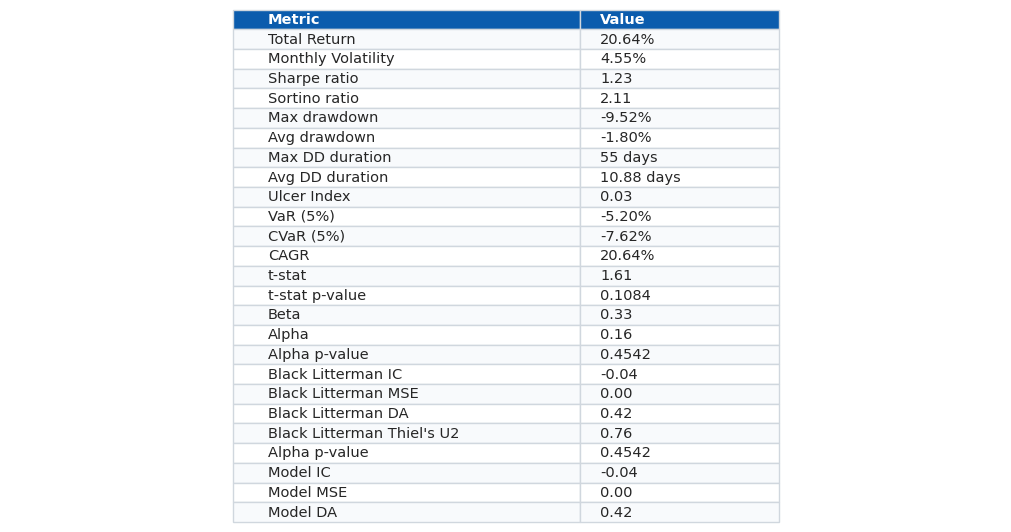

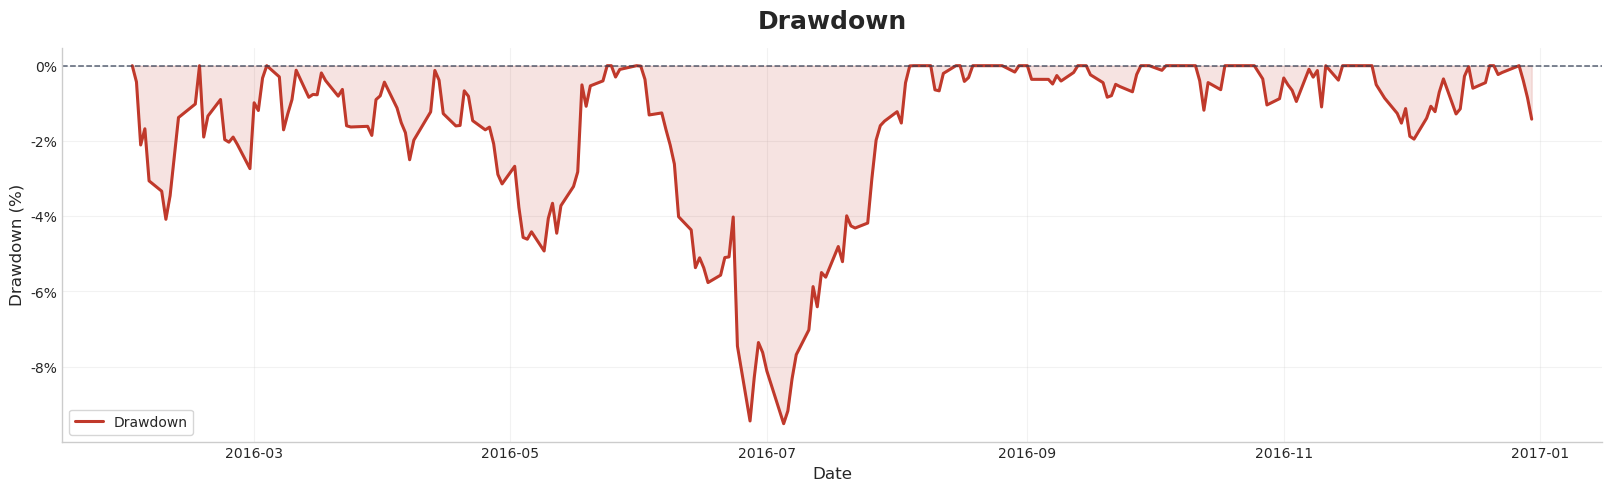

In [27]:
plt.style.use("seaborn-v0_8-whitegrid")

def as_scalar(value):
    array_value = np.asarray(value)
    if array_value.ndim == 0:
        return float(array_value)
    return float(np.nanmean(array_value))

daily_pct = daily_res["Portfolio Growth"].to_numpy() * 100
drawdown_pct = dds.to_numpy() * 100

daily_pct = pd.Series(daily_pct, index=daily_res.index)
drawdown_pct = pd.Series(drawdown_pct, index=daily_res.index)
daily_pct.iloc[0] = 100
drawdown_pct.iloc[0] = 0

fig, ax = plt.subplots(figsize=(16, 7), constrained_layout=True)
ax.plot(
    daily_pct.index,
    daily_pct.values,
    color="#0B5CAD",
    linewidth=2.7,
    label="Portfolio",
)
ax.fill_between(
    daily_pct.index,
    daily_pct.values,
    100,
    color="#0B5CAD",
    alpha=0.08,
)
ax.set_title("Linear Regression Black Litterman Monthly Rebalance Performance", fontsize=20, fontweight="bold", pad=16)
ax.set_ylabel("Portfolio value (% of initial capital)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, which="major", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper left", frameon=True)

plt.show()

metrics = [
    ("Total Return", f"{as_scalar(total_portfolio_value- 1):.2%}"),
    ("Monthly Volatility", f"{as_scalar(portfolio_volatility_value):.2%}"),
    ("Sharpe ratio", f"{as_scalar(sharpe_ratio_value):.2f}"),
    ("Sortino ratio", f"{as_scalar(sortino_ratio_value):.2f}"),
    ("Max drawdown", f"{as_scalar(max_dd):.2%}"),
    ("Avg drawdown", f"{as_scalar(average_dd_depth):.2%}"),
    ("Max DD duration", f"{as_scalar(max_dd_duration):.0f} days"),
    ("Avg DD duration", f"{as_scalar(average_dd_duration):.2f} days"),
    ("Ulcer Index", f"{as_scalar(ulcer_index_value):.2f}"),
    ("VaR (5%)", f"{as_scalar(var_value):.2%}"),
    ("CVaR (5%)", f"{as_scalar(cvar_value):.2%}"),
    ("CAGR", f"{as_scalar(cagr_value):.2%}"),
    ("t-stat", f"{as_scalar(t_statistic):.2f}"),
    ("t-stat p-value", f"{as_scalar(t_p_value):.4f}"),
    ("Beta", f"{as_scalar(beta):.2f}"),
    ("Alpha", f"{as_scalar(alpha):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}"),
    ("Black Litterman IC", f"{as_scalar(bl_IC):.2f}"),
    ("Black Litterman MSE", f"{as_scalar(bl_MSE):.2f}"),
    ("Black Litterman DA", f"{as_scalar(bl_DA):.2f}"),
    ("Black Litterman Thiel's U2", f"{as_scalar(bl_U2):.2f}"),
    ("Alpha p-value", f"{as_scalar(a_p_value):.4f}"),
    ("Model IC", f"{as_scalar(bl_IC):.2f}"),
    ("Model MSE", f"{as_scalar(bl_MSE):.2f}"),
    ("Model DA", f"{as_scalar(bl_DA):.2f}")
]

metrics_df = pd.DataFrame(metrics, columns=["Metric", "Value"])
fig_table, ax_table = plt.subplots(figsize=(10, 5.2), constrained_layout=True)
ax_table.axis("off")
table = ax_table.table(
    cellText=metrics_df.values,
    colLabels=metrics_df.columns,
    cellLoc="left",
    colLoc="left",
    loc="center",
    colWidths=[0.35, 0.2],
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1, 1.2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#D0D7DE")
    if row == 0:
        cell.set_facecolor("#0B5CAD")
        cell.set_text_props(color="white", weight="bold")
    elif row % 2 == 1:
        cell.set_facecolor("#F8FAFC")
    else:
        cell.set_facecolor("white")

plt.show()

fig_dd, ax_dd = plt.subplots(figsize=(16, 4.8), constrained_layout=True)
ax_dd.plot(
    drawdown_pct.index,
    drawdown_pct.values,
    color="#C0392B",
    linewidth=2.2,
    label="Drawdown",
)
ax_dd.axhline(0, color="#2F3B52", linewidth=1.1, linestyle="--", alpha=0.8)
ax_dd.fill_between(drawdown_pct.index, drawdown_pct.values, 0, color="#C0392B", alpha=0.14)
ax_dd.set_title("Drawdown", fontsize=18, fontweight="bold", pad=14)
ax_dd.set_ylabel("Drawdown (%)", fontsize=12)
ax_dd.set_xlabel("Date", fontsize=12)
ax_dd.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax_dd.grid(True, which="major", alpha=0.25)
ax_dd.spines["top"].set_visible(False)
ax_dd.spines["right"].set_visible(False)
ax_dd.legend(loc="lower left", frameon=True)

plt.show()